#     COURSE: Linear algebra: theory and implementation
##    SECTION: Eigendecomposition
###     VIDEO: Finding eigenvalues

#### Instructor: sincxpress.com
##### Course url: https://www.udemy.com/course/linear-algebra-theory-and-implementation/?couponCode=202110

In [113]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from numpy import linalg as LA
from rich import print
from rich.console import Console
from sklearn.datasets import fetch_openml, make_classification

console = Console()

In [71]:
%matplotlib inline

In [3]:
from contextlib import redirect_stdout
from io import StringIO


def rich_output(function, *args, **kwargs):
    buffer = StringIO()

    with redirect_stdout(buffer):
        result = function(*args, **kwargs)

    if text := buffer.getvalue():
        console.print(text)
    elif result is not None:
        console.print(result)


In [5]:
steel_X: pd.DataFrame
steel_y: pd.Series

steel_X, steel_y = fetch_openml(data_id=1504, as_frame=True, return_X_y=True)


In [6]:
rich_output(steel_X.describe)

V1           V2            V3            V4             V5  \
count  1941.000000  1941.000000  1.941000e+03  1.941000e+03    1941.000000   
mean    571.136012   617.964451  1.650685e+06  1.650739e+06    1893.878413   
std     520.690671   497.627410  1.774578e+06  1.774590e+06    5168.459560   
min       0.000000     4.000000  6.712000e+03  6.724000e+03       2.000000   
25%      51.000000   192.000000  4.712530e+05  4.712810e+05      84.000000   
50%     435.000000   467.000000  1.204128e+06  1.204136e+06     174.000000   
75%    1053.000000  1072.000000  2.183073e+06  2.183084e+06     822.000000   
max    1705.000000  1713.000000  1.298766e+07  1.298769e+07  152655.000000   

                 V6            V7            V8           V9          V10  \
count   1941.000000   1941.000000  1.941000e+03  1941.000000  1941.000000   
mean     111.855229     82.965997  2.063121e+05    84.548686   130.193715   
std      301.209187    426.482879  5.122936e+05    32.134276    18.690992   
min        2.000000      1.000000  2.500000e+02     0.000000    37.000000   
25%       15.000000     13.000000  9.522000e+03    63.000000   124.000000   
50%       26.000000     25.000000  1.920200e+04    90.000000   127.000000   
75%       84.000000     83.000000  8.301100e+04   106.000000   140.000000   
max    10449.000000  18152.000000  1.159141e+07   203.000000   253.000000   

       ...          V24          V25          V26          V27          V28  \
count  ...  1941.000000  1941.000000  1941.000000  1941.000000  1941.000000   
mean   ...     1.403271     0.083288    -0.131305     0.585420     0.081401   
std    ...     0.454345     0.500868     0.148767     0.339452     0.273521   
min    ...     0.000000    -0.991000    -0.998900     0.119000     0.000000   
25%    ...     1.079200    -0.333300    -0.195000     0.248200     0.000000   
50%    ...     1.322200     0.095200    -0.133000     0.506300     0.000000   
75%    ...     1.732400     0.511600    -0.066600     0.999800     0.000000   
max    ...     4.258700     0.991700     0.642100     1.000000     1.000000   

               V29          V30          V31          V32          V33  
count  1941.000000  1941.000000  1941.000000  1941.000000  1941.000000  
mean      0.097888     0.201443     0.037094     0.028336     0.207110  
std       0.297239     0.401181     0.189042     0.165973     0.405339  
min       0.000000     0.000000     0.000000     0.000000     0.000000  
25%       0.000000     0.000000     0.000000     0.000000     0.000000  
50%       0.000000     0.000000     0.000000     0.000000     0.000000  
75%       0.000000     0.000000     0.000000     0.000000     0.000000  
max       1.000000     1.000000     1.000000     1.000000     1.000000  

[8 rows x 33 columns]

In [7]:
X: np.ndarray
y: np.ndarray

X, y = make_classification(
    n_samples=100,
    n_features=100,
    n_informative=50,
    n_redundant=20,
    n_repeated=10,
    n_classes=5,
    return_X_y=True,
    random_state=1,
)

In [8]:
X.shape

(100, 100)

In [9]:
eigenvalues, eigenvectors = LA.eig(X)
print(eigenvalues)

[-5.01658140e+01+7.32072372e+01j -5.01658140e+01-7.32072372e+01j
  6.60393048e+01+2.92956652e+01j  6.60393048e+01-2.92956652e+01j
  3.37478829e+01+6.22366712e+01j  3.37478829e+01-6.22366712e+01j
 -6.69962475e+01+2.66709168e+01j -6.69962475e+01-2.66709168e+01j
 -1.07075162e+01+5.47911687e+01j -1.07075162e+01-5.47911687e+01j
  9.15510651e+00+5.34601755e+01j  9.15510651e+00-5.34601755e+01j
  5.13679141e+01+9.14432445e+00j  5.13679141e+01-9.14432445e+00j
 -3.61898639e+01+4.02362135e+01j -3.61898639e+01-4.02362135e+01j
  3.68536366e+01+0.00000000e+00j  3.51004614e+01+1.25452080e+01j
  3.51004614e+01-1.25452080e+01j -3.27334116e+01+2.54531870e+01j
 -3.27334116e+01-2.54531870e+01j  1.80549938e+01+2.98361327e+01j
  1.80549938e+01-2.98361327e+01j  6.30364344e+00+3.35817678e+01j
  6.30364344e+00-3.35817678e+01j -3.50393668e+01+0.00000000e+00j
 -2.17809064e+01+2.56254116e+01j -2.17809064e+01-2.56254116e+01j
 -9.05578392e+00+3.13789718e+01j -9.05578392e+00-3.13789718e+01j
 -3.04353185e+01+0.00000000e+00j -2.92533923e+01+1.12970363e+01j
 -2.92533923e+01-1.12970363e+01j  2.13257496e+01+2.02416917e+01j
  2.13257496e+01-2.02416917e+01j -2.88546967e+01+0.00000000e+00j
  2.33196122e+01+0.00000000e+00j -6.86479099e+00+2.11103312e+01j
 -6.86479099e+00-2.11103312e+01j  1.19686565e+01+1.32818202e+01j
  1.19686565e+01-1.32818202e+01j -1.40970314e+01+9.71385988e+00j
 -1.40970314e+01-9.71385988e+00j -1.62020559e+01+0.00000000e+00j
  1.38188190e+01+3.73834732e+00j  1.38188190e+01-3.73834732e+00j
  6.66687238e+00+1.14385154e+01j  6.66687238e+00-1.14385154e+01j
  8.88952574e-01+1.29507016e+01j  8.88952574e-01-1.29507016e+01j
 -8.17028163e+00+9.56008333e+00j -8.17028163e+00-9.56008333e+00j
 -1.11436403e+01+0.00000000e+00j  1.06020110e+01+0.00000000e+00j
  6.08732784e+00+7.29950638e+00j  6.08732784e+00-7.29950638e+00j
 -2.30915983e-01+7.91739229e+00j -2.30915983e-01-7.91739229e+00j
 -7.54067743e+00+2.17029484e+00j -7.54067743e+00-2.17029484e+00j
 -4.21865232e+00+5.60168682e+00j -4.21865232e+00-5.60168682e+00j
 -6.03379573e+00+0.00000000e+00j  2.76237183e+00+3.96713706e+00j
  2.76237183e+00-3.96713706e+00j  4.04583643e+00+0.00000000e+00j
  8.70834708e-01+3.60796394e+00j  8.70834708e-01-3.60796394e+00j
  3.05465931e+00+0.00000000e+00j  2.06633853e+00+0.00000000e+00j
 -2.58946365e-13+0.00000000e+00j -1.07799070e-13+0.00000000e+00j
  1.00964993e-13+0.00000000e+00j  5.00172378e-14+6.53648186e-14j
  5.00172378e-14-6.53648186e-14j -5.69328175e-14+0.00000000e+00j
 -1.72241538e-14+4.03947011e-14j -1.72241538e-14-4.03947011e-14j
  3.34168605e-14+2.24196034e-14j  3.34168605e-14-2.24196034e-14j
 -2.65332337e-14+0.00000000e+00j  6.02270806e-15+2.20307765e-14j
  6.02270806e-15-2.20307765e-14j  1.89201422e-14+1.46841674e-14j
  1.89201422e-14-1.46841674e-14j -9.92697951e-15+1.76087657e-14j
 -9.92697951e-15-1.76087657e-14j  1.93397116e-14+0.00000000e+00j
 -6.25766199e-15+1.15144071e-14j -6.25766199e-15-1.15144071e-14j
 -1.35951261e-14+7.23211851e-15j -1.35951261e-14-7.23211851e-15j
 -1.38506437e-14+0.00000000e+00j  1.01179123e-14+3.94962477e-15j
  1.01179123e-14-3.94962477e-15j -5.65369191e-15+2.43921740e-15j
 -5.65369191e-15-2.43921740e-15j  9.87994411e-15+0.00000000e+00j
 -7.91703406e-16+0.00000000e+00j  2.34751770e-15+0.00000000e+00j]

In [10]:
eigvec0 = eigenvectors[:, 0]
eigval0 = eigenvalues[0]
Xv0 = X @ eigvec0

In [11]:
Xv0.shape, eigvec0.shape

((100,), (100,))

So `X @ v` is a scalar multiple of `v`, not necessarily the exact same vector. The scalar is the corresponding eigenvalue $\lambda$.

In NumPy, eigenvectors are stored as **columns**, so use:

```python
eigenvalues, eigenvectors = np.linalg.eig(X)

lam = eigenvalues[0]
v = eigenvectors[:, 0]   # first eigenvector

Xv = X @ v

np.allclose(Xv, lam * v)
```

This should return `True`.

To inspect the numerical error:

```python
residual = np.linalg.norm(Xv - lam * v)
print(residual)
```

The relationship is a special kind of linear combination: `Xv` is exactly one scalar multiple of `v`. A general linear combination would look like:

$$
c_1v_1+c_2v_2+\cdots+c_nv_n
$$

but for an eigenvector, only one vector is needed:

$$
Xv = \lambda v
$$

In [12]:
np.allclose(Xv0, eigvec0 * eigval0)

True

In [13]:
residual = np.linalg.norm(Xv0 - eigvec0 * eigval0)
print(residual)


2.4526649576464066e-13

In [29]:
X_2_2 = np.diag([1, 2])
eigenvalues, eigenvectors = LA.eig(X_2_2)
print(eigenvalues, eigenvectors)

[1.+0.j 2.+0.j] [[1.+0.j 0.+0.j]
 [0.+0.j 1.+0.j]]

In [30]:
X_5_5 = np.diag(np.arange(1, 6))
eigenvalues, eigenvectors = LA.eig(X_5_5)
print(eigenvalues, eigenvectors)

[1.+0.j 2.+0.j 3.+0.j 4.+0.j 5.+0.j] [[1.+0.j 0.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 1.+0.j 0.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 1.+0.j 0.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 1.+0.j 0.+0.j]
 [0.+0.j 0.+0.j 0.+0.j 0.+0.j 1.+0.j]]

Lower Triangle matrix

In [39]:
X_5_5_tril = np.tril(np.arange(1, 26))
eigenvalues, eigenvectors = LA.eig(X_5_5_tril)
print(eigenvalues.real, eigenvectors.real)

[25. 24. 23. 22. 21. 20. 19. 18. 17. 16. 15. 14. 13. 12. 11. 10.  9.  8.
  7.  6.  5.  4.  3.  2.  1.] [[ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   6.62326415e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  2.97456763e-01
  -6.62326415e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  1.21956292e-01 -5.94913527e-01
   3.31163207e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  4.83614569e-02 -3.65868875e-01  5.94913527e-01
  -1.10387736e-01]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   1.88454073e-02 -1.93445828e-01  5.48803313e-01 -3.96609018e-01
   2.75969340e-02]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  7.26453311e-03
  -9.42270363e-02  3.86891655e-01 -5.48803313e-01  1.98304509e-01
  -5.51938679e-03]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  2.77972434e-03 -4.35871987e-02
   2.35567591e-01 -5.15855540e-01  4.11602485e-01 -7.93218036e-02
   9.19897798e-04]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  1.05795725e-03 -1.94580704e-02  1.30761596e-01
  -3.92612651e-01  5.15855540e-01 -2.46961491e-01  2.64406012e-02
  -1.31413971e-04]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   4.01108249e-04 -8.46365800e-03  6.81032464e-02 -2.61523192e-01
   4.90765814e-01 -4.12684432e-01  1.23480745e-01 -7.55445748e-03
   1.64267464e-05]
 [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
   0.00000000e+00  0.00000000e

Upper Triangle Matrix

In [38]:
X_5_5_triu = np.triu(np.arange(1, 26))
eigenvalues, eigenvectors = LA.eig(X_5_5_triu)
print(eigenvalues.real, eigenvectors.real)


[ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10. 11. 12. 13. 14. 15. 16. 17. 18.
 19. 20. 21. 22. 23. 24. 25.] [[1.00000000e+00 8.94427191e-01 8.18181818e-01 7.64291484e-01
  7.23813662e-01 6.91870326e-01 6.65736824e-01 6.43774224e-01
  6.24931485e-01 6.08499093e-01 5.93977911e-01 5.81004789e-01
  5.69308046e-01 5.58679604e-01 5.48956889e-01 5.40010671e-01
  5.31736672e-01 5.24049640e-01 5.16879054e-01 5.10165978e-01
  5.03860690e-01 4.97920894e-01 4.92310332e-01 4.86997711e-01
  4.81955846e-01]
 [0.00000000e+00 4.47213595e-01 5.45454545e-01 5.73218613e-01
  5.79050930e-01 5.76558605e-01 5.70631564e-01 5.63302446e-01
  5.55494654e-01 5.47649184e-01 5.39979919e-01 5.32587724e-01
  5.25515119e-01 5.18773918e-01 5.12359763e-01 5.06260004e-01
  5.00458045e-01 4.94935771e-01 4.89674894e-01 4.84657679e-01
  4.79867324e-01 4.75288126e-01 4.70905535e-01 4.66706140e-01
  4.62677612e-01]
 [0.00000000e+00 0.00000000e+00 1.81818182e-01 2.86609306e-01
  3.47430558e-01 3.84372403e-01 4.07593974e-01 4.22476834e-01
  4.32051397e-01 4.38119347e-01 4.41801752e-01 4.43823103e-01
  4.44666639e-01 4.44663358e-01 4.44045128e-01 4.42977503e-01
  4.41580628e-01 4.39942908e-01 4.38130168e-01 4.36191911e-01
  4.34165674e-01 4.32080114e-01 4.29957228e-01 4.27813961e-01
  4.25663403e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 7.16523266e-02
  1.38972223e-01 1.92186202e-01 2.32910842e-01 2.64048021e-01
  2.88034265e-01 3.06683543e-01 3.21310365e-01 3.32867327e-01
  3.42051261e-01 3.49378353e-01 3.55236103e-01 3.59919222e-01
  3.63654635e-01 3.66619090e-01 3.68951720e-01 3.70763124e-01
  3.72142006e-01 3.73160099e-01 3.73875850e-01 3.74337216e-01
  3.74583795e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  2.77944446e-02 6.40620672e-02 9.98189324e-02 1.32024011e-01
  1.60019036e-01 1.84010126e-01 2.04470232e-01 2.21911552e-01
  2.36804719e-01 2.49555966e-01 2.60506475e-01 2.69939416e-01
  2.78088838e-01 2.85148181e-01 2.91277674e-01 2.96610500e-01
  3.01257815e-01 3.05312808e-01 3.08853963e-01 3.11947680e-01
  3.14650388e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 1.06770112e-02 2.85196950e-02 4.95090040e-02
  7.11195716e-02 9.20050629e-02 1.11529218e-01 1.29448405e-01
  1.45725981e-01 1.60428836e-01 1.73670984e-01 1.85583349e-01
  1.96298003e-01 2.05940353e-01 2.14625655e-01 2.22457875e-01
  2.29529763e-01 2.35923534e-01 2.41711797e-01 2.46958580e-01
  2.51720310e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 4.07424214e-03 1.23772510e-02
  2.37065239e-02 3.68020252e-02 5.06950989e-02 6.47242025e-02
  7.84678359e-02 9.16736203e-02 1.04202590e-01 1.15989593e-01
  1.27016355e-01 1.37293569e-01 1.46849132e-01 1.55720512e-01
  1.63949831e-01 1.71580752e-01 1.78656546e-01 1.85218935e-01
  1.91307436e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 1.54715638e-03
  5.26811641e-03 1.10406075e-02 1.84345814e-02 2.69684177e-02
  3.62159243e-02 4.58368102e-02 5.55747147e-02 6.52441460e-02
  7.47155030e-02 8.39016252e-02 9.27468203e-02 1.01218333e-01
  1.09299887e-01 1.16986876e-01 1.24282815e-01 1.31196746e-01
  1.37741354e-01]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  5.85346268e-04 2.20812151e-03 5.02761312e-03 8.98947257e-03
  1.39292016e-02 1.96443472e-02 2.59348669e-02 3.26220730e-02
  3.95552663e-02 4.66120140e-02 5.36955275e-02 6.07309998e-02
  6.76618350e-02 7.44461939e-02 8.10540095e-02 8.74644971e-02
  9.36641205e-02]
 [0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
  0.00000000e+00 2.20812151e-04 9.14111476e-04 2.24736814e-03
  4.28590820e-03 7.01583829e-03 1.03739468e-02 1.42721569e-02
  1.86142430e-02 2.33060070e-02 2.82608040e-02 3.34020499e-02
  3.86639057e-02 4.39909328e-02 4.93372232e-02 5.46653107e-02
  5.99450371e-0

In [90]:
A = np.random.randint(-1000, 1001, (40, 40))
eigenvalues, eigenvectors = LA.eig(A)

In [94]:
eigenlist: list[float] = []
for _ in range(1000):
    A = np.random.randint(-1000, 1001, (40, 40))
    eigenvalues, eigenvectors = LA.eig(A)
    eigenlist.extend(eigenvalues)

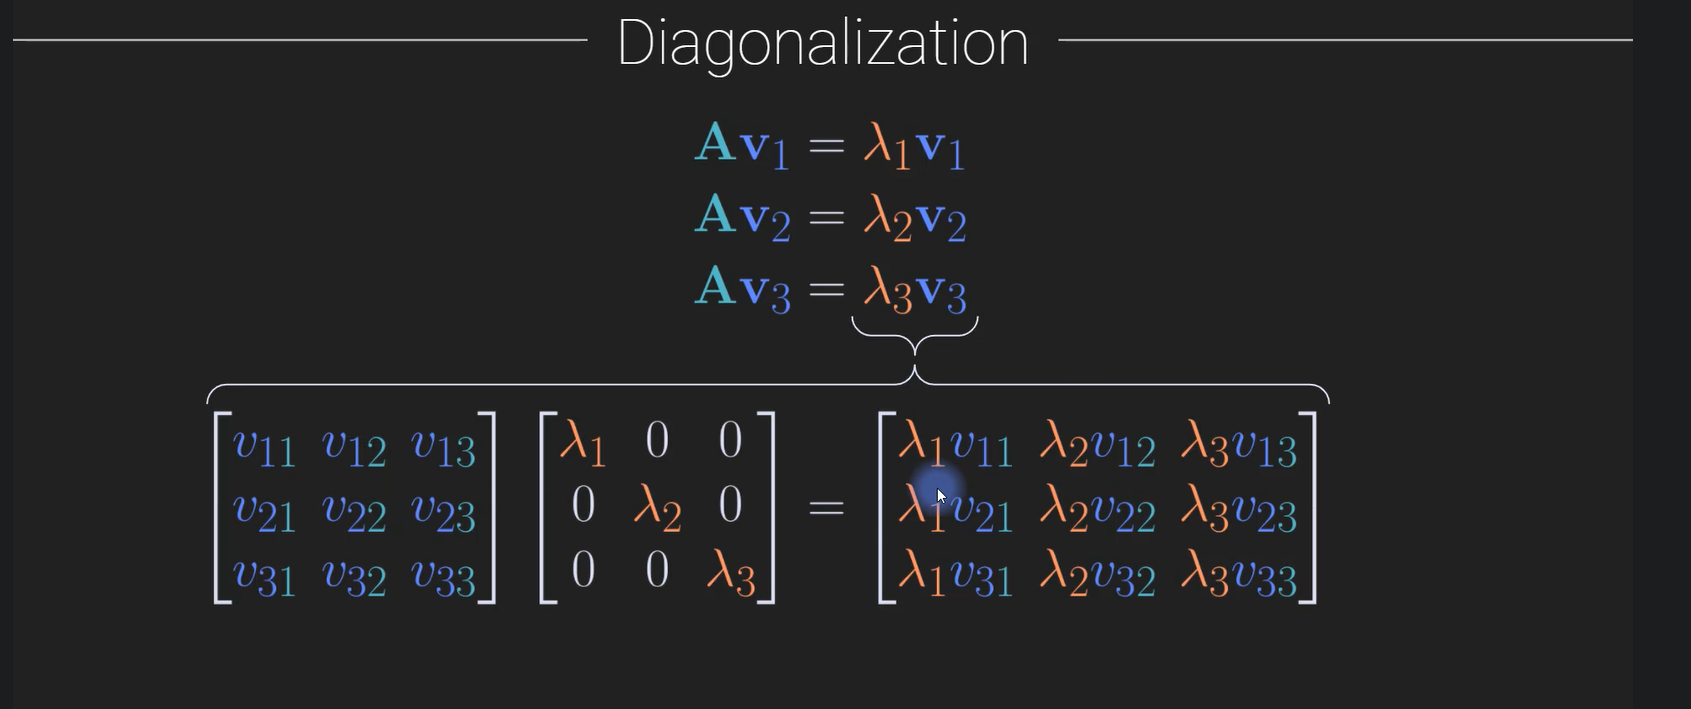

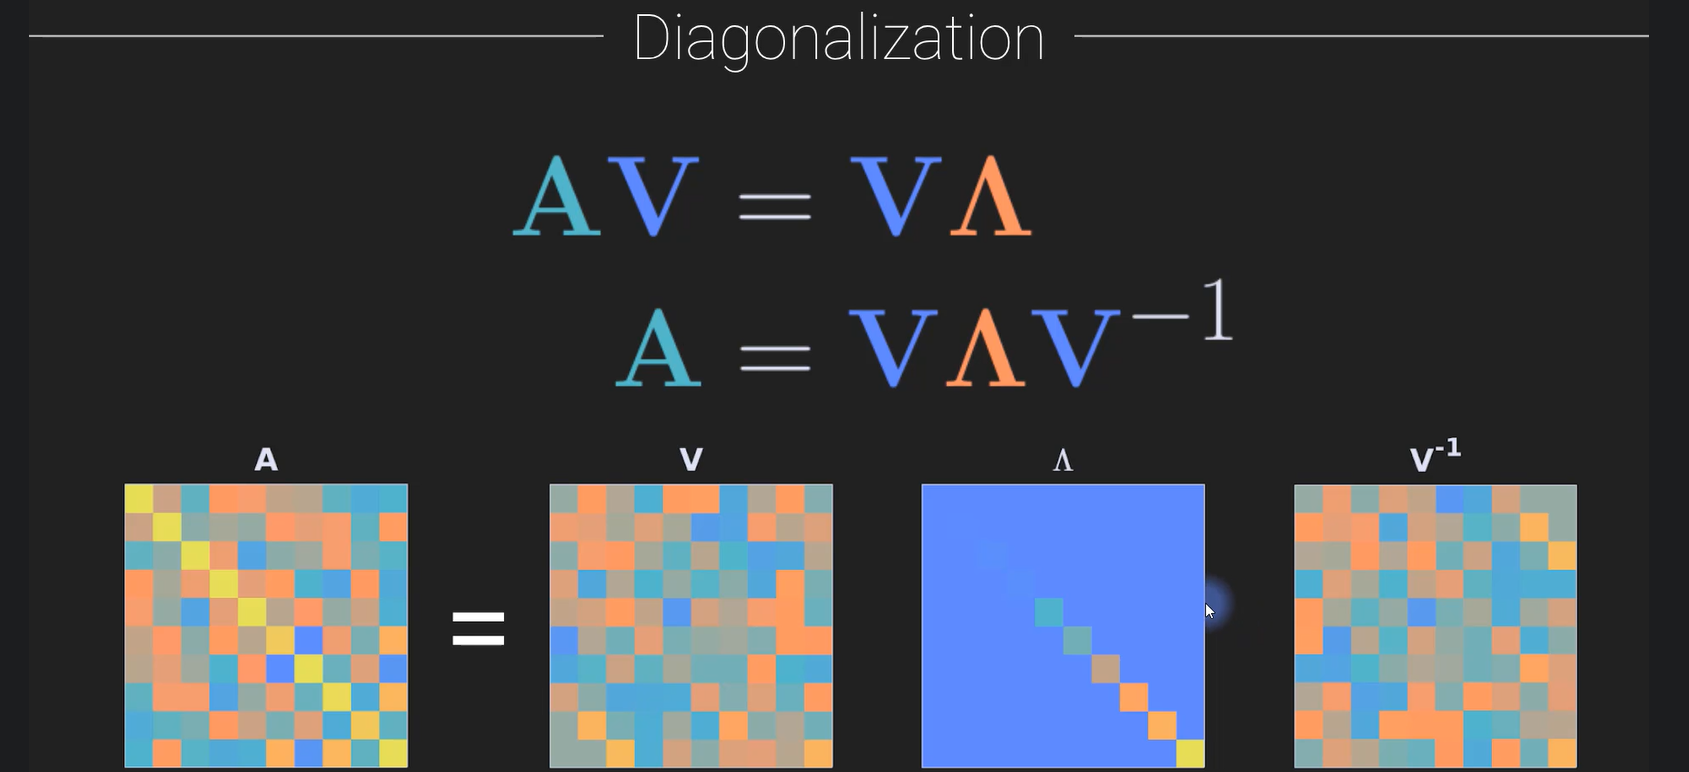

In [114]:
from sklearn.datasets import make_classification

X: np.ndarray
y: np.ndarray

X, y = make_classification(
    n_samples=50,
    n_features=50,
    n_informative=50,
    n_redundant=0,
    n_repeated=0,
    n_classes=3,
    return_X_y=True,
    random_state=1,
)

In [115]:
eigenvalues, V = LA.eig(X)
V_inverse = LA.inv(V)
eigen_diag = np.diag(eigenvalues)

In [105]:
eigen_diag

array([[ 28.50308879+5.36854922j,   0.        +0.j        ,
          0.        +0.j        , ...,   0.        +0.j        ,
          0.        +0.j        ,   0.        +0.j        ],
       [  0.        +0.j        ,  28.50308879-5.36854922j,
          0.        +0.j        , ...,   0.        +0.j        ,
          0.        +0.j        ,   0.        +0.j        ],
       [  0.        +0.j        ,   0.        +0.j        ,
        -27.49815916+9.20825568j, ...,   0.        +0.j        ,
          0.        +0.j        ,   0.        +0.j        ],
       ...,
       [  0.        +0.j        ,   0.        +0.j        ,
          0.        +0.j        , ...,  -0.12701282+1.21420961j,
          0.        +0.j        ,   0.        +0.j        ],
       [  0.        +0.j        ,   0.        +0.j        ,
          0.        +0.j        , ...,   0.        +0.j        ,
         -0.12701282-1.21420961j,   0.        +0.j        ],
       [  0.        +0.j        ,   0.        +0.j        

In [106]:
# Sort complex values consistently
eigenvalues_sorted = np.sort_complex(eigenvalues)

# Compare neighboring complex eigenvalues
differences = np.diff(eigenvalues_sorted)

tolerance = 1e-10
all_unique = np.all(np.abs(differences) > tolerance)

print("All eigenvalues are unique:", all_unique)


All eigenvalues are unique: True

In [116]:
X_recon = V @ eigen_diag @ V_inverse

In [110]:
np.allclose(X_recon, X)

True

An easy way to compare matrices is to plot them as raster images

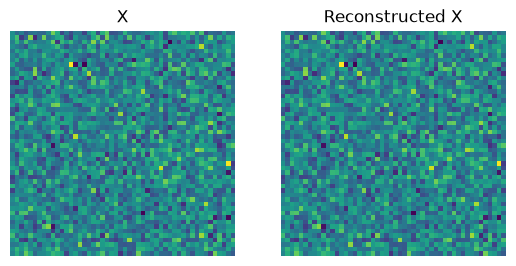

In [117]:
X_recon_display = np.real_if_close(X_recon, tol=1000)

plt.subplot(121)
plt.imshow(X)
plt.axis("off")
plt.title("X")

plt.subplot(122)
plt.imshow(X_recon_display)
plt.axis("off")
plt.title("Reconstructed X")

plt.show()